# KMeans Clustering - Wine

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# DATASET LOAD

In [2]:
name = "Wine"

data = load_wine()
X = data.data

In [3]:
df = pd.DataFrame(X)
print(f"Dataset Name: {name}")
print("Dataset Shape:", df.shape)
df.head()

Dataset Name: Wine
Dataset Shape: (178, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


# Model Training using Different K values

In [5]:
k_values = range(2, 15)

wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)

    wcss.append(inertia)
    sil_scores.append(sil)

    # ✅ BOTH PRINTED TOGETHER (YOUR REQUEST)
    print(f"k={k}, inertia={round(inertia,2)}, silhouette={round(sil,4)}")

k=2, inertia=4543749.61, silhouette=0.6569
k=3, inertia=2370689.69, silhouette=0.5711
k=4, inertia=1331903.06, silhouette=0.562
k=5, inertia=916379.19, silhouette=0.549
k=6, inertia=647326.0, silhouette=0.5656
k=7, inertia=412303.83, silhouette=0.5622
k=8, inertia=323211.55, silhouette=0.5407
k=9, inertia=273154.33, silhouette=0.5248
k=10, inertia=217936.8, silhouette=0.5213
k=11, inertia=187872.16, silhouette=0.5182
k=12, inertia=167265.59, silhouette=0.5109
k=13, inertia=150322.7, silhouette=0.5046
k=14, inertia=123117.37, silhouette=0.5029


## Elbow Method and Silhouette Score

In [6]:
print("WCSS:", wcss)
print("\nSilhouette Scores:", sil_scores)

WCSS: [4543749.614531862, 2370689.686782968, 1331903.0622637183, 916379.1871539169, 647326.0020260847, 412303.8282508013, 323211.55263465445, 273154.3322663098, 217936.79696044207, 187872.1573061708, 167265.58649208373, 150322.70167066655, 123117.36865064378]

Silhouette Scores: [0.6568536504294317, 0.5711381937868838, 0.5620323449580341, 0.5489993239795675, 0.5656413100386369, 0.5621677013863696, 0.5406824747857603, 0.524796938056894, 0.5212721803377277, 0.5181954752644797, 0.5108763154601352, 0.504572885325198, 0.5028981685867965]


### Plots

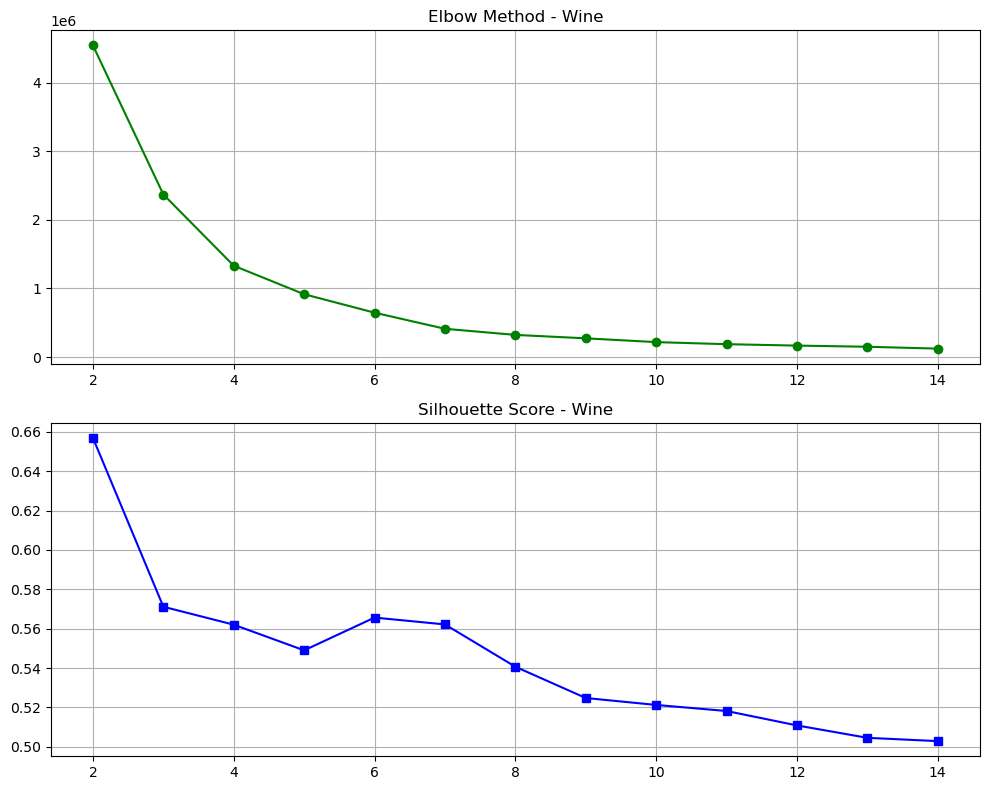

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(k_values, wcss, marker="o", color="green")
axes[0].set_title(f"Elbow Method - {name}")
axes[0].grid(True)

axes[1].plot(k_values, sil_scores, marker="s", color="blue")
axes[1].set_title(f"Silhouette Score - {name}")
axes[1].grid(True)

plt.savefig("Elbow Method and Silhouette Score (Wine).png",dpi=100)
plt.tight_layout()
plt.show()

## Best K

In [8]:
best_k_wcss = list(k_values)[np.argmax(wcss)]
best_k_sil = list(k_values)[np.argmax(sil_scores)]

print(f"Best k (WCSS): {best_k_wcss}")
print(f"Best k (Silhouette): {best_k_sil}")

Best k (WCSS): 2
Best k (Silhouette): 2


### Model Training using Best K value

In [10]:
final_k = best_k_sil
kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)

print(f"k={k}, inertia={round(kmeans.inertia_,2)}, silhouette={round(silhouette_score(X, clusters),4)}")

k=14, inertia=4543749.61, silhouette=0.6569


#### Plot

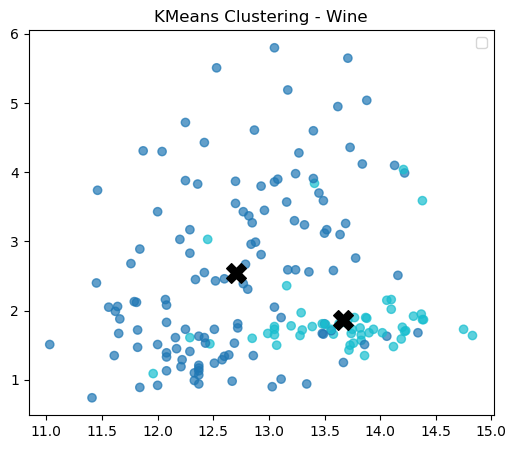

In [13]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap="tab10", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, marker="X", color="black")
plt.title(f"KMeans Clustering - {name}")
plt.savefig("KMeans Clustering (Wine).png",dpi=100)
plt.legend()
plt.show()